# PyTorch Exercises: From Basics to Custom Backprop

**TIFR PreSchool 2026 — ML School**

This notebook is a graded set of exercises. Each section introduces a concept and then asks you to fill in the empty solution cell that follows.

**How to use this notebook**
- Run the *setup* cell first.
- Read the prompt, then write your answer in the cell marked `# Your code here`.
- Some exercises include `assert` statements — your solution is (probably) correct when they pass silently.
- If you get stuck, look up the relevant function in the [PyTorch docs](https://pytorch.org/docs/stable/index.html).

**Outline**

1. Tensors and basic operations
2. Broadcasting, indexing, reshaping
3. Autograd — automatic differentiation
4. Building models with `nn.Module`
5. Datasets, `DataLoader`, and a training loop
6. Custom loss functions
7. Custom optimizers (writing your own SGD, Momentum, RMSProp, Adam)
8. Custom autograd functions (forward + backward by hand)
9. Hooks, gradient surgery, higher-order gradients
10. Putting it all together: a tiny end-to-end project

## Setup

Run this cell once at the start of the session.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

torch.manual_seed(0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch version:', torch.__version__)
print('Device:', device)

PyTorch version: 2.13.0
Device: cpu


---
## 1. Tensors and basic operations

A `torch.Tensor` is a multi-dimensional array with a `dtype`, a `device`, and (optionally) a `requires_grad` flag.

Useful constructors:
- `torch.tensor(data)` — from a Python list / NumPy array
- `torch.zeros`, `torch.ones`, `torch.eye`, `torch.arange`, `torch.linspace`
- `torch.randn`, `torch.rand`, `torch.randint`
- `.to(device)`, `.float()`, `.long()` for conversions

### Exercise 1.1 — Build a few tensors

Create the following tensors:

1. `a` — a `float32` tensor of shape `(3, 4)` filled with zeros.
2. `b` — the 5×5 identity matrix.
3. `c` — a tensor containing the integers 0, 2, 4, ..., 18 (i.e. even numbers from 0 up to 18 inclusive).
4. `d` — a `(2, 3, 4)` tensor of standard-normal random numbers.

Print each tensor's `shape` and `dtype`.

In [2]:
a = torch.zeros(3, 4, dtype=torch.float32)
b = torch.eye(5)
c = torch.arange(0, 20, 2)
d = torch.randn(2, 3, 4)

for name, tensor in {"a": a, "b": b, "c": c, "d": d}.items():
    print(name, tensor.shape, tensor.dtype)

a torch.Size([3, 4]) torch.float32
b torch.Size([5, 5]) torch.float32
c torch.Size([10]) torch.int64
d torch.Size([2, 3, 4]) torch.float32


### Exercise 1.2 — Element-wise math vs. matrix math

Given two random matrices `X` of shape `(4, 3)` and `Y` of shape `(3, 5)`:

1. Compute their **matrix product** `Z` of shape `(4, 5)` two different ways: with `@` and with `torch.matmul`.
2. Compute the element-wise product of `X` with itself.
3. Compute the sum of all elements of `Z`, the column-wise mean (one value per column), and the row-wise max.

Verify the two matrix-product results agree using `torch.allclose`.

In [3]:
X = torch.randn(4, 3)
Y = torch.randn(3, 5)

Z1 = X @ Y
Z2 = torch.matmul(X, Y)

print(torch.allclose(Z1, Z2))
print((X * X).shape)
print(Z1.sum())
print(Z1.mean(dim=0))
print(Z1.max(dim=1).values)


True
torch.Size([4, 3])
tensor(-1.1047)
tensor([-0.2153, -0.2221, -0.0736, -0.1278,  0.3626])
tensor([0.2163, 0.0432, 3.6122, 2.5468])


---
## 2. Broadcasting, indexing, reshaping

Broadcasting lets you operate on tensors of different shapes without writing loops, as long as their trailing dimensions are *compatible* (equal, or one of them is 1).

### Exercise 2.1 — Standardise the columns of a matrix

Given a matrix `M` of shape `(N, D)`, write code that produces `M_std` where each column has mean 0 and standard deviation 1. **Use broadcasting — no explicit loops.**

After your code, the asserts below should pass.

In [4]:
M = torch.randn(100, 5) * torch.tensor([1., 2., 3., 4., 5.]) + torch.tensor([10., -3., 0., 7., 1.])

# Compute the mean of each column.
# keepdim=True keeps the result shape as (1, D), so broadcasting works cleanly.
column_mean = M.mean(dim=0, keepdim=True)

# Compute the standard deviation of each column.
# unbiased=False matches the assert below and the usual normalization formula here.
column_std = M.std(dim=0, keepdim=True, unbiased=False)

# Standardise each column: subtract the mean and divide by the std.
M_std = (M - column_mean) / column_std

assert torch.allclose(M_std.mean(dim=0), torch.zeros(5), atol=1e-5)
assert torch.allclose(M_std.std(dim=0, unbiased=False), torch.ones(5), atol=1e-5)
print('OK')

OK


### Exercise 2.2 — Reshape and permute

Start from `T = torch.arange(24)`.

1. Reshape `T` to shape `(2, 3, 4)` and call it `T1`.
2. Permute `T1`'s axes so the result has shape `(4, 2, 3)`. Call it `T2`.
3. Flatten `T2` back to a 1-D tensor `T3`.
4. Is `T3` equal to `T`? Why or why not?

In [5]:
T = torch.arange(24)

# Reshape the flat tensor into a 3D tensor with shape (2, 3, 4).
T1 = T.reshape(2, 3, 4)

# Reorder the axes to get shape (4, 2, 3).
T2 = T1.permute(2, 0, 1)

# Flatten the permuted tensor back to 1D.
T3 = T2.flatten()

print('T1 shape:', T1.shape)
print('T2 shape:', T2.shape)
print('T3 shape:', T3.shape)
print('T3 equals T:', torch.equal(T3, T))

# T3 is usually not equal to T because permute changes the element order
# as seen by flattening, even though the same values are still present.


T1 shape: torch.Size([2, 3, 4])
T2 shape: torch.Size([4, 2, 3])
T3 shape: torch.Size([24])
T3 equals T: False


### Exercise 2.3 — Boolean / fancy indexing

Given `x = torch.randn(1000)`:

1. Build a mask that selects the entries of `x` strictly greater than 1.
2. Replace those entries (in a copy `y`) with the value `1.0`. The original `x` should be untouched.
3. Report the fraction of entries that were clipped.

In [6]:
x = torch.randn(1000)

# Boolean mask for values strictly greater than 1.
mask = x > 1

# Work on a copy so the original tensor stays unchanged.
y = x.clone()

# Replace only the masked entries.
y[mask] = 1.0

# Fraction of entries that were clipped.
fraction_clipped = mask.float().mean()

print("Number clipped:", mask.sum().item())
print("Fraction clipped:", fraction_clipped.item())
print("x unchanged:", torch.equal(x, y) == False)
print("Max of y:", y.max().item())

Number clipped: 169
Fraction clipped: 0.16899999976158142
x unchanged: True
Max of y: 1.0


---
## 3. Autograd

PyTorch's `autograd` engine records operations on tensors that have `requires_grad=True` into a dynamic computation graph, then computes gradients on demand via `.backward()`.

Key ideas:
- Only **leaf** tensors with `requires_grad=True` accumulate gradients in `.grad`.
- `.backward()` traverses the graph in reverse, multiplying Jacobian-vector products.
- Call `tensor.detach()` to break a tensor out of the graph; wrap code in `torch.no_grad()` to disable tracking entirely.

### Exercise 3.1 — Gradient of a scalar function by hand and by autograd

Let $f(x) = 3x^3 - 5x^2 + 2x - 7$. Analytically, $f'(x) = 9x^2 - 10x + 2$.

1. Create `x = torch.tensor(2.0, requires_grad=True)`.
2. Compute `y = f(x)`, then `y.backward()`.
3. Check that `x.grad` equals $9 \cdot 2^2 - 10 \cdot 2 + 2 = 18$.

In [7]:
# Define x as a scalar tensor that tracks gradients.
x = torch.tensor(2.0, requires_grad=True)

# Compute f(x) = 3x^3 - 5x^2 + 2x - 7.
y = 3 * x**3 - 5 * x**2 + 2 * x - 7

# Backpropagate from the scalar output.
y.backward()

# For x = 2, the derivative is 9x^2 - 10x + 2 = 18.
print("y:", y.item())
print("x.grad:", x.grad.item())


y: 1.0
x.grad: 18.0


### Exercise 3.2 — Gradient of a vector-valued function

Let $\mathbf{w} \in \mathbb{R}^3$ and $\mathbf{x} \in \mathbb{R}^3$, and define
$$L = \tfrac{1}{2} \| \mathbf{w} \odot \mathbf{x} - \mathbf{t} \|_2^2$$
for some target `t`.

Compute `dL/dw` for the given numerical values, using autograd. Then check it against the closed-form expression $\nabla_\mathbf{w} L = (\mathbf{w}\odot\mathbf{x} - \mathbf{t}) \odot \mathbf{x}$.

In [8]:
w = torch.tensor([0.5, -1.0, 2.0], requires_grad=True)
x = torch.tensor([1.0, 2.0, -0.5])
t = torch.tensor([0.0, 0.0, 1.0])

# Compute the prediction w x x.
pred = w * x

# Loss: 1/2 ||pred - t||^2
loss = 0.5 * ((pred - t) ** 2).sum()

# Backpropagate to get dL/dw.
loss.backward()

# Closed-form gradient: (w x x - t) x x
expected = (w.detach() * x - t) * x

print("w.grad:", w.grad)
print("expected:", expected)
print("matches:", torch.allclose(w.grad, expected))

w.grad: tensor([ 0.5000, -4.0000,  1.0000])
expected: tensor([ 0.5000, -4.0000,  1.0000])
matches: True


### Exercise 3.3 — `detach`, `no_grad`, and gradient accumulation

Build a small experiment that demonstrates each of these behaviours. For a parameter `p = torch.tensor(1.0, requires_grad=True)`:

1. Compute the gradient of `loss = p**2` twice in a row, **without** calling `p.grad.zero_()` in between. What is `p.grad` after the second call?
2. Repeat, but call `p.grad.zero_()` between the two backward passes.
3. Show that `(p.detach() ** 2).backward()` fails (or produces no gradient).
4. Show that operations inside `with torch.no_grad():` produce tensors with `requires_grad=False`.

In [9]:
# Use a scalar parameter that tracks gradients.
p = torch.tensor(1.0, requires_grad=True)

# First backward pass.
loss = p**2
loss.backward()
print("After first backward:", p.grad.item())  # 2.0

# Second backward pass without clearing .grad first.
loss = p**2
loss.backward()
print("After second backward without zeroing:", p.grad.item())  # 4.0

# Clear the accumulated gradient.
p.grad.zero_()

# Third backward pass after zeroing.
loss = p**2
loss.backward()
print("After zeroing and backward again:", p.grad.item())  # 2.0

# Detach breaks the computation graph, so backward will fail here.
try:
    (p.detach() ** 2).backward()
except RuntimeError as error:
    print("Detached backward error:", error)

# no_grad disables gradient tracking.
with torch.no_grad():
    q = p * 3

print("q.requires_grad:", q.requires_grad)


After first backward: 2.0
After second backward without zeroing: 4.0
After zeroing and backward again: 2.0
Detached backward error: element 0 of tensors does not require grad and does not have a grad_fn
q.requires_grad: False


---
## 4. Building models with `nn.Module`

Anything trainable in PyTorch is conventionally a subclass of `nn.Module`. You register `nn.Parameter`s (which automatically appear in `.parameters()`) and submodules; you implement `forward(...)`.

Building blocks worth knowing:
- `nn.Linear`, `nn.Conv2d`, `nn.LayerNorm`, `nn.Embedding`
- `nn.ReLU`, `nn.GELU`, `nn.Tanh`
- `nn.Sequential`, `nn.ModuleList`, `nn.ModuleDict`

### Exercise 4.1 — An MLP from scratch (no `nn.Linear`)

Implement a 2-layer MLP **without** using `nn.Linear` — instantiate the weights and biases yourself as `nn.Parameter`s. The model should map `D_in → H → D_out` with a `tanh` non-linearity in between.

Initialise weights with Kaiming-style scaling: `W ~ N(0, 2/fan_in)`.

In [10]:
class MyMLP(nn.Module):
    def __init__(self, d_in, hidden, d_out):
        super().__init__()
        # Think of this as building the network by hand instead of using nn.Linear.
        # W1 connects the input to the hidden layer.
        # b1 shifts the hidden activations.
        self.W1 = nn.Parameter(torch.randn(hidden, d_in) * math.sqrt(2.0 / d_in))
        self.b1 = nn.Parameter(torch.zeros(hidden))

        # W2 connects the hidden layer to the output.
        # b2 shifts the output values.
        self.W2 = nn.Parameter(torch.randn(d_out, hidden) * math.sqrt(2.0 / hidden))
        self.b2 = nn.Parameter(torch.zeros(d_out))

    def forward(self, x):
        # First linear step: input -> hidden.
        hidden = x @ self.W1.t() + self.b1

        # tanh is the non-linearity that makes the model more expressive.
        hidden = torch.tanh(hidden)

        # Second linear step: hidden -> output.
        return hidden @ self.W2.t() + self.b2

# Smoke test: the model should accept a batch of 5 examples with 8 features each
# and return 5 predictions with 4 output values each.
m = MyMLP(8, 16, 4)
out = m(torch.randn(5, 8))
print(out.shape)
print(sum(p.numel() for p in m.parameters()))

torch.Size([5, 4])
212


### Exercise 4.2 — The same MLP using `nn.Sequential`

Re-implement the model above using `nn.Linear` layers wrapped in `nn.Sequential`. Confirm that the parameter count matches your hand-built version.

In [11]:
# This version uses PyTorch's built-in building blocks instead of hand-made weights.
# nn.Linear already knows how to store weights and biases for us.
# nn.Sequential lets us stack the layers in order, one after another.

model = nn.Sequential(
    nn.Linear(8, 16),  # input layer -> hidden layer
    nn.Tanh(),  # non-linearity
    nn.Linear(16, 4),  # hidden layer -> output layer
)

# Smoke test: pass a batch of 5 examples, each with 8 input features.
out = model(torch.randn(5, 8))

print(out.shape)  # should be torch.Size([5, 4])

# Compare parameter counts with the hand-built version from Exercise 4.1.
m = MyMLP(8, 16, 4)

count_seq = sum(p.numel() for p in model.parameters())
count_manual = sum(p.numel() for p in m.parameters())

print("Sequential parameter count:", count_seq)
print("Manual parameter count:", count_manual)
print("Counts match:", count_seq == count_manual)


torch.Size([5, 4])
Sequential parameter count: 212
Manual parameter count: 212
Counts match: True


### Exercise 4.3 — Parameter counting and `.state_dict()`

Write a function `count_params(model, trainable_only=True)` that returns the total number of parameters. Use it on your MLP.

Then save the model's `state_dict()` to a file and load it back into a fresh instance. Verify the outputs match on a random input.

In [12]:
from pathlib import Path

def count_params(model, trainable_only=True):
    # Count how many scalar numbers live inside the model's tensors.
    params = model.parameters() if not trainable_only else (p for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in params)

# Use the Sequential MLP from Exercise 4.2.
print("Trainable parameters:", count_params(model))
print("All parameters:", count_params(model, trainable_only=False))

# Save the learned weights to a small local file.
state_path = Path("exercise_4_3_state_dict.pt")
torch.save(model.state_dict(), state_path)

# Build a fresh copy with the same architecture and load the saved weights.
fresh_model = nn.Sequential(
    nn.Linear(8, 16),
    nn.Tanh(),
    nn.Linear(16, 4),
)
fresh_model.load_state_dict(torch.load(state_path, map_location=device))

# Check that both models produce the same output on the same random input.
x_test = torch.randn(3, 8)
with torch.no_grad():
    y_old = model(x_test)
    y_new = fresh_model(x_test)

print("Outputs match:", torch.allclose(y_old, y_new))


Trainable parameters: 212
All parameters: 212
Outputs match: True


---
## 5. Datasets, `DataLoader`, and a training loop

PyTorch separates **datasets** (random-access containers of examples) from **data loaders** (which batch, shuffle, and parallelise). The minimal training loop is:

```python
for epoch in range(num_epochs):
    for xb, yb in loader:
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```

### Exercise 5.1 — A toy regression dataset

Generate a synthetic dataset for the function $y = \sin(2\pi x) + 0.1\,\varepsilon$ with $x \in [0, 1]$ and Gaussian noise $\varepsilon$. Make 1000 training points and 200 validation points. Wrap them in `TensorDataset`s and `DataLoader`s with batch size 32.

In [13]:
# Make the input x values uniformly spaced in [0, 1].
# x has shape [N, 1] so it behaves like a single-feature dataset.
train_x = torch.rand(1000, 1)
val_x = torch.rand(200, 1)

# Add a small amount of Gaussian noise to the clean sine wave.
train_y = torch.sin(2 * torch.pi * train_x) + 0.1 * torch.randn_like(train_x)
val_y = torch.sin(2 * torch.pi * val_x) + 0.1 * torch.randn_like(val_x)

# Wrap the tensors in TensorDataset objects so each item is (x, y).
train_dataset = TensorDataset(train_x, train_y)
val_dataset = TensorDataset(val_x, val_y)

# DataLoader handles batching and shuffling for us during training.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(len(train_dataset), len(val_dataset))
print(next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape)


1000 200
torch.Size([32, 1]) torch.Size([32, 1])


### Exercise 5.2 — Train an MLP on it

Use your `MyMLP` (or the `nn.Sequential` version) with `d_in=1`, `hidden=64`, `d_out=1`. Train for, say, 200 epochs with `MSELoss` and `torch.optim.Adam(lr=1e-2)`. Log the average training and validation loss per epoch and plot them.

Epoch 000 | train loss = 0.279929 | val loss = 0.188651
Epoch 020 | train loss = 0.116727 | val loss = 0.103247
Epoch 040 | train loss = 0.015899 | val loss = 0.015752
Epoch 060 | train loss = 0.012792 | val loss = 0.014927
Epoch 080 | train loss = 0.012621 | val loss = 0.011459
Epoch 100 | train loss = 0.011982 | val loss = 0.012592
Epoch 120 | train loss = 0.012108 | val loss = 0.010600
Epoch 140 | train loss = 0.011473 | val loss = 0.010184
Epoch 160 | train loss = 0.013547 | val loss = 0.014296
Epoch 180 | train loss = 0.013111 | val loss = 0.010027
Epoch 199 | train loss = 0.011336 | val loss = 0.012925


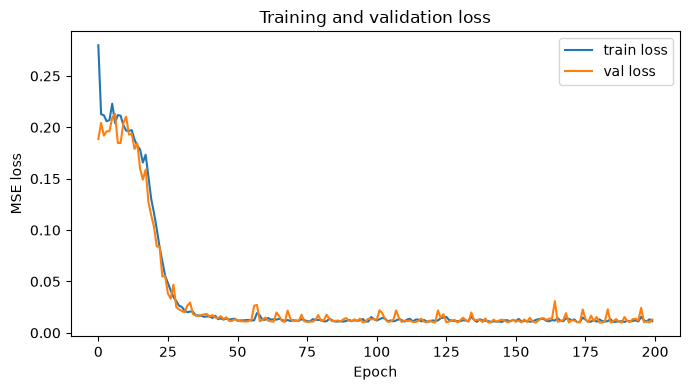

In [14]:
import matplotlib.pyplot as plt

# Build a fresh model for the 1D regression problem.
# The input has one feature, the hidden layer is wider, and the output is one value.
model = nn.Sequential(
    nn.Linear(1, 64),
    nn.Tanh(),
    nn.Linear(64, 1),
).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

train_losses = []
val_losses = []

for epoch in range(200):
    # Training phase: update the weights using the training batches.
    model.train()
    running_train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        pred = model(xb)
        loss = loss_fn(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * xb.size(0)

    avg_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(avg_train_loss)

    # Validation phase: measure loss without changing the model.
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            running_val_loss += loss_fn(pred, yb).item() * xb.size(0)

    avg_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(avg_val_loss)

    if epoch % 20 == 0 or epoch == 199:
        print(f'Epoch {epoch:03d} | train loss = {avg_train_loss:.6f} | val loss = {avg_val_loss:.6f}')

# Plot the learning curves so we can see whether the model is fitting well.
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Training and validation loss')
plt.legend()
plt.tight_layout()
plt.show()


### Exercise 5.3 — Plot the fitted curve

On a dense grid of `x` values in `[0, 1]`, predict `y_hat` (under `torch.no_grad()` and in `model.eval()` mode), and plot the predictions against the true sine and the noisy training points.

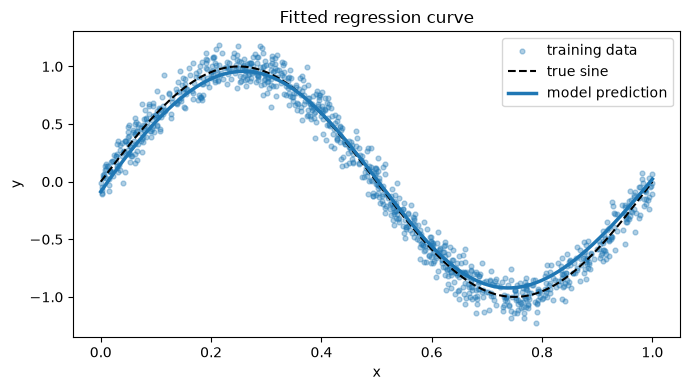

In [15]:
import matplotlib.pyplot as plt

# Build a smooth grid so we can see the learned curve clearly.
x_grid = torch.linspace(0, 1, 400).unsqueeze(1).to(device)

# Switch to evaluation mode and turn off gradient tracking.
model.eval()
with torch.no_grad():
    y_hat = model(x_grid).cpu()

# The true function is the clean sine wave without noise.
x_plot = x_grid.cpu()
y_true = torch.sin(2 * torch.pi * x_plot)

# Plot the noisy training samples, the true curve, and the model prediction.
plt.figure(figsize=(7, 4))
plt.scatter(train_x.cpu(), train_y.cpu(), s=12, alpha=0.35, label='training data')
plt.plot(x_plot, y_true, 'k--', label='true sine')
plt.plot(x_plot, y_hat, linewidth=2.5, label='model prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Fitted regression curve')
plt.legend()
plt.tight_layout()
plt.show()


---
## 6. Custom loss functions

A loss function is just a differentiable function from `(prediction, target)` to a scalar. You can write it as a plain Python function or as an `nn.Module` (handy when it has learnable parameters or state).

### Exercise 6.1 — Huber loss

Implement the Huber loss
$$\ell_\delta(r) = \begin{cases} \tfrac{1}{2} r^2 & |r| \le \delta \\ \delta\,(|r| - \tfrac{1}{2}\delta) & |r| > \delta \end{cases}$$
where $r = \hat{y} - y$. Take the **mean** over the batch.

Sanity check: for very small residuals it should agree with $\tfrac{1}{2}\text{MSE}$; for very large residuals it should grow linearly. Compare against `nn.SmoothL1Loss(beta=delta)` (note the small difference: `SmoothL1` uses $r^2/(2\delta)$ on the inside, not $r^2/2$).

In [16]:
def huber_loss(pred, target, delta=1.0):
    # Residual is just prediction minus target.
    residual = pred - target
    abs_residual = residual.abs()

    # Quadratic near zero, linear in the tails.
    quadratic = 0.5 * residual**2
    linear = delta * (abs_residual - 0.5 * delta)

    # Pick the right branch for each element, then average over the batch.
    loss = torch.where(abs_residual <= delta, quadratic, linear)
    return loss.mean()

# Small smoke test: compare the two branches on easy inputs.
pred = torch.tensor([0.0, 0.5, 3.0])
target = torch.zeros(3)
print(huber_loss(pred, target, delta=1.0))
print(F.smooth_l1_loss(pred, target, beta=1.0))


tensor(0.8750)
tensor(0.8750)


### Exercise 6.2 — Cross-entropy from scratch (numerically stable)

Implement multi-class cross-entropy from raw logits *without* calling `F.cross_entropy`, `F.log_softmax`, or `nn.LogSoftmax`.

Use the log-sum-exp trick:
$$\log\sum_j e^{z_j} = m + \log\sum_j e^{z_j - m}, \quad m = \max_j z_j$$

Verify your result against `F.cross_entropy` to within `1e-6`.

In [17]:
def my_cross_entropy(logits, targets):
    """logits: (N, C); targets: (N,) long class indices. Returns scalar mean loss."""
    # Shift logits for numerical stability.
    max_logits = logits.max(dim=1, keepdim=True).values
    shifted = logits - max_logits

    # log(sum(exp(logits))) in a stable way.
    log_sum_exp = torch.log(torch.exp(shifted).sum(dim=1, keepdim=True))

    # Log-probabilities for each class.
    log_probs = shifted - log_sum_exp

    # Pick the log-probability of the correct class for each sample.
    nll = -log_probs[torch.arange(targets.shape[0]), targets]

    # Mean over the batch.
    return nll.mean()


# Smoke test
logits = torch.randn(8, 5)
targets = torch.randint(0, 5, (8,))
loss1 = my_cross_entropy(logits, targets)
loss2 = F.cross_entropy(logits, targets)
print(loss1, loss2)
print(torch.allclose(loss1, loss2, atol=1e-6))


tensor(1.9657) tensor(1.9657)
True


---
## 7. Custom optimizers

A PyTorch optimizer is a class with a `.step()` method that, after `loss.backward()` has populated `p.grad`, updates each parameter `p` in place. We will write four optimizers from scratch.

The skeleton looks like:

```python
class MyOpt:
    def __init__(self, params, lr):
        self.params = list(params)
        self.lr = lr
        self.state = {id(p): {} for p in self.params}

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue
            # update p in place

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()
```

All updates **must** happen under `torch.no_grad()` (or use `p.data` / `p.add_`) so we don't track them in the graph.

### Exercise 7.1 — Plain SGD

Implement `MySGD` with the update
$$\theta \leftarrow \theta - \eta\, g.$$

In [18]:
class MySGD:
    def __init__(self, params, lr=1e-2):
        self.params = list(params)
        self.lr = lr

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue
            p -= self.lr * p.grad

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()


### Exercise 7.2 — SGD with momentum (Polyak)

Implement the heavy-ball update:
$$v \leftarrow \mu\, v + g, \qquad \theta \leftarrow \theta - \eta\, v.$$
Initialise `v` to zeros the first time you see each parameter.

In [19]:
class MyMomentum:
    def __init__(self, params, lr=1e-2, momentum=0.9):
        self.params = list(params)
        self.lr = lr
        self.momentum = momentum
        self.state = {id(p): torch.zeros_like(p) for p in self.params}

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue
            buf = self.state[id(p)]
            buf.mul_(self.momentum).add_(p.grad)
            p -= self.lr * buf

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()


### Exercise 7.3 — RMSProp

Implement RMSProp:
$$s \leftarrow \alpha\, s + (1-\alpha)\, g^2, \qquad \theta \leftarrow \theta - \frac{\eta}{\sqrt{s} + \epsilon}\, g.$$

In [20]:
class MyRMSProp:
    def __init__(self, params, lr=1e-3, alpha=0.99, eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.alpha = alpha
        self.eps = eps
        self.state = {id(p): torch.zeros_like(p) for p in self.params}

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue
            s = self.state[id(p)]
            s.mul_(self.alpha).addcmul_(p.grad, p.grad, value=1 - self.alpha)
            p -= self.lr * p.grad / (s.sqrt() + self.eps)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()


### Exercise 7.4 — Adam

Implement Adam with bias correction:
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\hat m_t = m_t / (1 - \beta_1^t), \quad \hat v_t = v_t / (1 - \beta_2^t)$$
$$\theta_t = \theta_{t-1} - \eta\, \hat m_t / (\sqrt{\hat v_t} + \epsilon)$$

Track the step count $t$ per parameter (it is the same for all, but you'll want it stored).

In [21]:
class MyAdam:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.state = {
            id(p): {
                "m": torch.zeros_like(p),
                "v": torch.zeros_like(p),
                "t": 0,
            }
            for p in self.params
        }

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue

            state = self.state[id(p)]
            state["t"] += 1

            g = p.grad
            state["m"].mul_(self.beta1).add_(g, alpha=1 - self.beta1)
            state["v"].mul_(self.beta2).addcmul_(g, g, value=1 - self.beta2)

            t = state["t"]
            m_hat = state["m"] / (1 - self.beta1**t)
            v_hat = state["v"] / (1 - self.beta2**t)

            p -= self.lr * m_hat / (v_hat.sqrt() + self.eps)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()


### Exercise 7.5 — Bake-off on the toy regression task

Train your sine-fitting MLP **four times** with identical initial weights, using `MySGD`, `MyMomentum`, `MyRMSProp`, and `MyAdam`. Plot the training-loss curve for each on the same axes. Comment on what you observe.

*Hint:* use `copy.deepcopy` on the freshly-initialised model so each optimizer starts from the same weights.

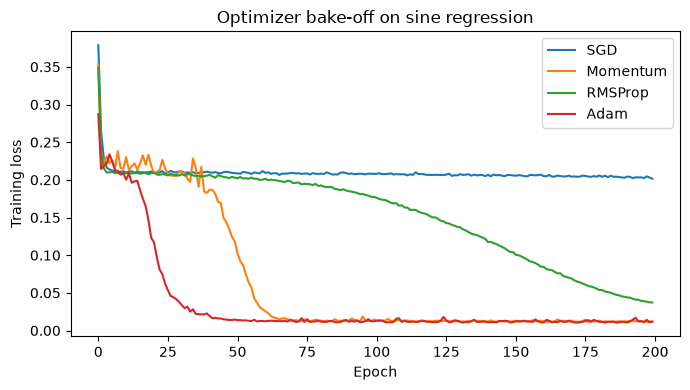

In [22]:
import copy
import matplotlib.pyplot as plt


def train_one_optimizer(model, optimizer_class, optimizer_kwargs, epochs=200):
    model = copy.deepcopy(model)
    optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)
    loss_fn = nn.MSELoss()

    losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        losses.append(running_loss / len(train_dataset))

    return losses


# Fresh base model so all optimizers start from identical weights.
base_model = nn.Sequential(
    nn.Linear(1, 64),
    nn.Tanh(),
    nn.Linear(64, 1),
).to(device)

losses_sgd = train_one_optimizer(base_model, MySGD, {"lr": 1e-2})
losses_momentum = train_one_optimizer(
    base_model, MyMomentum, {"lr": 1e-2, "momentum": 0.9}
)
losses_rmsprop = train_one_optimizer(
    base_model, MyRMSProp, {"lr": 1e-3, "alpha": 0.99, "eps": 1e-8}
)
losses_adam = train_one_optimizer(
    base_model, MyAdam, {"lr": 1e-2, "betas": (0.9, 0.999), "eps": 1e-8}
)

plt.figure(figsize=(7, 4))
plt.plot(losses_sgd, label="SGD")
plt.plot(losses_momentum, label="Momentum")
plt.plot(losses_rmsprop, label="RMSProp")
plt.plot(losses_adam, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Optimizer bake-off on sine regression")
plt.legend()
plt.tight_layout()
plt.show()


### Exercise 7.6 — Weight decay, properly

Add a `weight_decay` parameter to `MyAdam`. There are **two** common ways to apply it:

1. **L2 regularisation** — add `weight_decay * p` to the gradient *before* the moment updates.
2. **Decoupled weight decay (AdamW)** — apply `p -= lr * weight_decay * p` directly to the parameter, *separately* from the adaptive update.

Implement both as options. Discuss in a short comment why decoupled weight decay tends to behave better with Adam-family optimizers.

In [23]:
class MyAdam:
    def __init__(
        self,
        params,
        lr=1e-3,
        betas=(0.9, 0.999),
        eps=1e-8,
        weight_decay=0.0,
        decoupled_weight_decay=False,
    ):
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.weight_decay = weight_decay
        self.decoupled_weight_decay = decoupled_weight_decay

        self.state = {
            id(p): {
                "m": torch.zeros_like(p),
                "v": torch.zeros_like(p),
                "t": 0,
            }
            for p in self.params
        }

    @torch.no_grad()
    def step(self):
        for p in self.params:
            if p.grad is None:
                continue

            state = self.state[id(p)]
            state["t"] += 1

            g = p.grad

            # L2 regularisation: add weight decay into the gradient.
            if self.weight_decay != 0.0 and not self.decoupled_weight_decay:
                g = g + self.weight_decay * p

            state["m"].mul_(self.beta1).add_(g, alpha=1 - self.beta1)
            state["v"].mul_(self.beta2).addcmul_(g, g, value=1 - self.beta2)

            t = state["t"]
            m_hat = state["m"] / (1 - self.beta1**t)
            v_hat = state["v"] / (1 - self.beta2**t)

            # Decoupled weight decay: apply directly to the parameters.
            if self.weight_decay != 0.0 and self.decoupled_weight_decay:
                p.mul_(1 - self.lr * self.weight_decay)

            p -= self.lr * m_hat / (v_hat.sqrt() + self.eps)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

---
## 8. Custom autograd functions

Sometimes you need to define an operation whose forward or backward pass autograd doesn't already know about — e.g. a non-standard non-linearity, a discrete operation with a straight-through gradient, or a numerically tricky composite that you can simplify by hand.

The recipe is to subclass `torch.autograd.Function`:

```python
class MyFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, *inputs):
        ctx.save_for_backward(...)
        return output

    @staticmethod
    def backward(ctx, grad_output):
        (...) = ctx.saved_tensors
        return grad_inputs  # one per input to forward(), in the same order
```

Use `torch.autograd.gradcheck` (with `dtype=torch.float64`) to verify your backward is correct.

### Exercise 8.1 — `MySquare`

Warm-up. Implement `y = x**2` as a `torch.autograd.Function`. The derivative is `2x`, so the backward should return `grad_output * 2 * x`.

Verify with `gradcheck`.

In [24]:
class MySquare(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        # Save x for the backward pass.
        ctx.save_for_backward(x)
        return x**2

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        # d(x^2)/dx = 2x, so chain with the upstream gradient.
        return grad_output * 2 * x


### Exercise 8.2 — `MyReLU`

Implement ReLU as a custom autograd function. The derivative is 1 for `x > 0` and 0 otherwise (the choice at `x = 0` is a sub-gradient — 0 is the conventional pick).

Then verify with `gradcheck` (perturb only at non-zero points).

In [25]:
class MyReLU(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        # Save x so we can tell which entries were positive.
        ctx.save_for_backward(x)
        return torch.clamp(x, min=0)

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        # Gradient passes through only where x > 0.
        grad_x = grad_output.clone()
        grad_x[x <= 0] = 0
        return grad_x


### Exercise 8.3 — Numerically stable `MyLogSoftmax`

Implement log-softmax along a chosen dimension, with a hand-written backward.

Forward (use log-sum-exp for stability):
$$y_i = z_i - \log\sum_j e^{z_j}.$$

Backward — given upstream `g = ∂L/∂y`, the Jacobian of log-softmax is $I - \mathbf{1}\,\mathrm{softmax}(z)^\top$ along the chosen axis, so:
$$\frac{\partial L}{\partial z_i} = g_i - \left(\sum_j g_j\right) \cdot \mathrm{softmax}(z)_i.$$

Verify against `F.log_softmax` both forward (values) and backward (gradients) on a random input.

In [26]:
class MyLogSoftmax(torch.autograd.Function):
    @staticmethod
    def forward(ctx, z, dim):
        # Save the softmax probabilities and the dimension for backward.
        max_z = z.max(dim=dim, keepdim=True).values
        shifted = z - max_z
        log_sum_exp = torch.log(torch.exp(shifted).sum(dim=dim, keepdim=True))
        out = shifted - log_sum_exp
        softmax = torch.exp(out)
        ctx.save_for_backward(softmax)
        ctx.dim = dim
        return out

    @staticmethod
    def backward(ctx, grad_output):
        (softmax,) = ctx.saved_tensors
        dim = ctx.dim
        grad_sum = grad_output.sum(dim=dim, keepdim=True)
        grad_z = grad_output - grad_sum * softmax
        return grad_z, None


### Exercise 8.4 — Straight-through estimator

Implement `MyRound` whose forward is `torch.round(x)` (non-differentiable), but whose backward acts as the identity — i.e. `grad_x = grad_output`. This is the *straight-through estimator*, commonly used to backprop through discrete operations (quantisation, hard-attention, etc.).

Test that a tiny linear layer trained with `MyRound` in the middle still learns to fit `y = 3x + 1` on a small dataset.

In [27]:
class MyRound(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        return torch.round(x)

    @staticmethod
    def backward(ctx, grad_output):
        # Straight-through estimator: pretend rounding was the identity.
        return grad_output


### Exercise 8.5 — A composite op with a custom backward: `MySwish`

Swish is $f(x) = x \cdot \sigma(x)$, where $\sigma$ is the logistic sigmoid. Its derivative is
$$f'(x) = \sigma(x) + x\,\sigma(x)\,(1 - \sigma(x)) = f(x) + \sigma(x)\,(1 - f(x)).$$

Implement it as a `torch.autograd.Function` that saves only `sigmoid(x)` from the forward (so the backward is cheaper — no recompute). Verify with `gradcheck` and compare runtime against the naïve `x * torch.sigmoid(x)` version on a large tensor.

In [28]:
class MySwish(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        sigmoid = torch.sigmoid(x)
        ctx.save_for_backward(sigmoid, x)
        return x * sigmoid

    @staticmethod
    def backward(ctx, grad_output):
        sigmoid, x = ctx.saved_tensors
        grad_x = grad_output * (sigmoid + x * sigmoid * (1 - sigmoid))
        return grad_x


---
## 9. Hooks, gradient surgery, higher-order gradients

A few more advanced tools.

### Exercise 9.1 — Register a backward hook to log gradient norms

Pick any of your `nn.Linear` layers and use `module.register_full_backward_hook(...)` to print the L2 norm of the gradient flowing through it on each backward pass. Train for a few iterations and observe.

In [29]:
# Pick a model that has at least one Linear layer.
model = nn.Sequential(
    nn.Linear(2, 32),
    nn.ReLU(),
    nn.Linear(32, 2),
)


def log_grad_norm(module, grad_input, grad_output):
    if grad_output and grad_output[0] is not None:
        norm = grad_output[0].norm().item()
        print(f"{module.__class__.__name__} grad norm: {norm:.6f}")


hook_handle = model[0].register_full_backward_hook(log_grad_norm)

# Example training step
x = torch.randn(8, 2)
y = torch.randint(0, 2, (8,))
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

pred = model(x)
loss = loss_fn(pred, y)
optimizer.zero_grad()
loss.backward()
optimizer.step()

hook_handle.remove()


Linear grad norm: 0.109809


/var/folders/0s/9r0n20j90w36bt6vmbn27lp40000gn/T/ipykernel_57282/3570647559.py:26: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


### Exercise 9.2 — Gradient clipping by hand

Implement global-norm gradient clipping yourself (don't call `torch.nn.utils.clip_grad_norm_`). The recipe: compute `total_norm = sqrt(sum(g.pow(2).sum() for g in grads))`; if `total_norm > max_norm`, scale every gradient by `max_norm / (total_norm + 1e-6)`.

In [30]:
def clip_grad_norm(params, max_norm):
    grads = [p.grad for p in params if p.grad is not None]
    if not grads:
        return 0.0

    total_norm = torch.sqrt(sum(g.pow(2).sum() for g in grads))
    scale = max_norm / (total_norm + 1e-6)

    if total_norm > max_norm:
        for g in grads:
            g.mul_(scale)

    return total_norm.item()


### Exercise 9.3 — Second-order gradients

For $f(x, y) = x^2 y + y^3$ at the point $(1, 2)$, compute:

1. $\partial f / \partial x$ and $\partial f / \partial y$ using `torch.autograd.grad(..., create_graph=True)`.
2. The full $2\times 2$ Hessian matrix at $(1, 2)$ by differentiating each first-order gradient again.

Check against the closed form: $\nabla f = (2xy, x^2 + 3y^2)$ and Hessian = $\begin{pmatrix} 2y & 2x \\ 2x & 6y \end{pmatrix}$, which at $(1,2)$ is $\begin{pmatrix} 4 & 2 \\ 2 & 12 \end{pmatrix}$.

In [31]:
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

f = x**2 * y + y**3

grad_x, grad_y = torch.autograd.grad(f, (x, y), create_graph=True)
print("df/dx:", grad_x.item())
print("df/dy:", grad_y.item())

h_xx = torch.autograd.grad(grad_x, x, retain_graph=True)[0]
h_xy = torch.autograd.grad(grad_x, y, retain_graph=True)[0]
h_yx = torch.autograd.grad(grad_y, x, retain_graph=True)[0]
h_yy = torch.autograd.grad(grad_y, y, retain_graph=True)[0]

hessian = torch.tensor(
    [
        [h_xx.item(), h_xy.item()],
        [h_yx.item(), h_yy.item()],
    ]
)

print(hessian)


df/dx: 4.0
df/dy: 13.0
tensor([[ 4.,  2.],
        [ 2., 12.]])


---
## 10. Putting it all together

Build a small classifier on a real toy dataset using **your own** components throughout. This is open-ended — try to use as many of the pieces you wrote above as you can.

### Exercise 10 — Two-moons classification with your stack

1. Generate a `make_moons`-style dataset (you can use `sklearn.datasets.make_moons` or roll your own).
2. Build an MLP classifier (1 hidden layer of 32 units is enough). Use `MyReLU` or `MySwish` as the activation.
3. Train it with **your** `MyAdam`, using **your** `my_cross_entropy` as the loss.
4. Apply your hand-written gradient-norm clipping at every step with `max_norm=1.0`.
5. Plot the decision boundary, the training-loss curve, and final accuracy.

If everything is wired together correctly you should comfortably hit > 95% accuracy.

Epoch 000 | loss = 0.3784
Epoch 020 | loss = 0.0802
Epoch 040 | loss = 0.0695
Epoch 060 | loss = 0.0698
Epoch 080 | loss = 0.0648
Epoch 100 | loss = 0.0633
Epoch 120 | loss = 0.0661
Epoch 140 | loss = 0.0618
Epoch 160 | loss = 0.0627
Epoch 180 | loss = 0.0619
Epoch 199 | loss = 0.0656
Train accuracy: 0.9779999852180481
Test accuracy: 0.9639999866485596


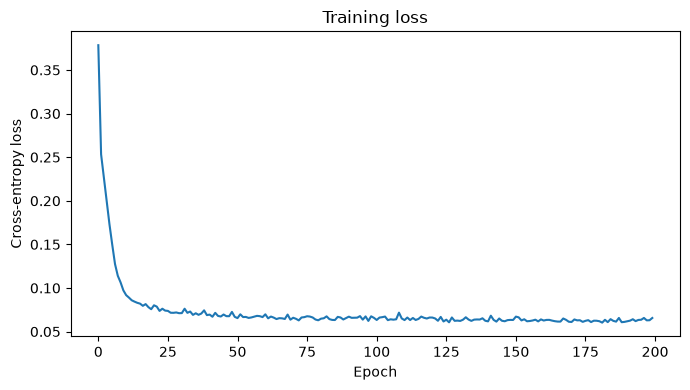

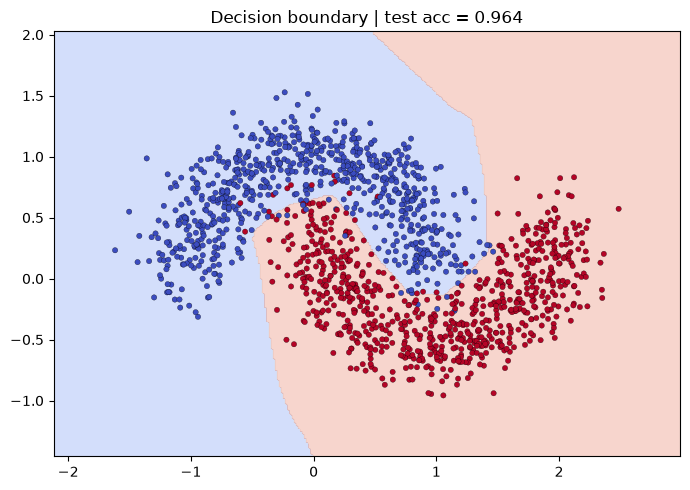

In [32]:
import copy
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import numpy as np

# 1) Data
X_np, y_np = make_moons(n_samples=2000, noise=0.2, random_state=0)
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.25, random_state=0, stratify=y_np
)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


# 2) Model
class MoonMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.fc1(x)
        x = MyReLU.apply(x)
        x = self.fc2(x)
        return x


base_model = MoonMLP().to(device)

# 3) Training setup
model = copy.deepcopy(base_model)
optimizer = MyAdam(model.parameters(), lr=1e-2)
loss_history = []

# 4) Train
for epoch in range(200):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = my_cross_entropy(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        clip_grad_norm(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    loss_history.append(running_loss / len(train_dataset))

    if epoch % 20 == 0 or epoch == 199:
        print(f"Epoch {epoch:03d} | loss = {loss_history[-1]:.4f}")

# 5) Accuracy
model.eval()
with torch.no_grad():
    train_pred = model(X_train.to(device)).argmax(dim=1).cpu()
    test_pred = model(X_test.to(device)).argmax(dim=1).cpu()

train_acc = (train_pred == y_train).float().mean().item()
test_acc = (test_pred == y_test).float().mean().item()

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

# 6) Loss curve
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training loss")
plt.tight_layout()
plt.show()

# 7) Decision boundary
x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)

with torch.no_grad():
    zz = model(grid).argmax(dim=1).cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, zz, alpha=0.3, levels=2, cmap="coolwarm")
plt.scatter(
    X_train_np[:, 0],
    X_train_np[:, 1],
    c=y_train_np,
    s=15,
    cmap="coolwarm",
    edgecolors="k",
    linewidths=0.2,
)
plt.title(f"Decision boundary | test acc = {test_acc:.3f}")
plt.tight_layout()
plt.show()


---
## Where to go next

If you finished the above:
- Re-do Exercise 7.4 (Adam) so that it supports **parameter groups** (different `lr` per group), like real `torch.optim` optimizers.
- Write a custom autograd function for **batch-norm** (forward + backward by hand) and compare against `nn.BatchNorm1d`.
- Read the source of `torch.optim.Adam` and `torch.nn.functional.cross_entropy` and compare them to your implementations.
- Look at `torch.func` (functorch) — `grad`, `vmap`, `jacrev` — and re-do the Hessian exercise in one line.